In [14]:
from sklearn.neighbors import NearestNeighbors
import glob
import pandas as pd
from astropy.cosmology import Planck18
from astropy import units as u
import numpy as np
from astropy.coordinates import SkyCoord
from scipy.stats import norm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [15]:
barred_target = pd.read_csv('../data/matched_barred_ps1_resolved.csv')
unbarred_target = pd.read_csv('../data/matched_unbarred_ps1_resolved.csv')

In [16]:
target = pd.read_csv('../all_sample_20260702.csv')
target = pd.merge(target, barred_target[['paliya_RA', 'class']], how='left', on='paliya_RA')
target = pd.merge(target, unbarred_target[['paliya_RA', 'class']], how='left', on='paliya_RA')
target['class'] = target['class_x'].combine_first(target['class_y'])
target = target.drop(['class_x', 'class_y'], axis=1)

target = target[target['class'].isin(['barred', 'unbarred'])]
tg_z = (target.paliya_Z).values
tg_d = Planck18.comoving_distance(target.paliya_Z).value
tg_ra = (target.paliya_RA).values
tg_dec = (target.paliya_DEC).values

coord = SkyCoord(ra = tg_ra * u.deg, dec = tg_dec * u.deg, distance = tg_d * u.Mpc)
tg_df = pd.DataFrame({'coord':coord})

In [ ]:
import numpy as np
import pandas as pd
import glob
from scipy.stats import norm
from astropy.cosmology import Planck18
from joblib import Parallel, delayed
import sys
from pathlib import Path

# ensure local code/ module is importable inside the notebook kernel
sys.path.insert(0, str(Path('.') / 'code'))
from ak_density_knn import compute_density_for_target_knn


def compute_index_for_target(i):
    # 1. read file and basic filters (keeps original variable names)
    file_list = glob.glob(f'../data/catalog/ps1/matched/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
    if len(file_list) == 0:
        return [-999] * 3

    target_z = float(target.paliya_Z.iloc[i])
    df = pd.read_csv(file_list[0])
    # df = df[df.Absolute_Mag_r < -20.5]
    if len(df) == 0:
        return [-999] * 3

    surround_z = df['z_phot0'].to_numpy(dtype=float)
    surround_err = df['z_photErr'].to_numpy(dtype=float)
    surround_ra = df.raMean.to_numpy(dtype=float)
    surround_dec = df.decMean.to_numpy(dtype=float)

    mask = (surround_z - surround_err / 2) > -1
    surround_z = surround_z[mask]
    surround_err = surround_err[mask]
    surround_ra = surround_ra[mask]
    surround_dec = surround_dec[mask]

    if len(surround_z) == 0:
        return [-999] * 3

    surround_d = Planck18.comoving_distance(surround_z).value
    valid = np.isfinite(surround_d) & (surround_d >= 0)
    surround_z = surround_z[valid]
    surround_err = surround_err[valid]
    surround_ra = surround_ra[valid]
    surround_dec = surround_dec[valid]
    surround_d = surround_d[valid]

    if len(surround_d) == 0:
        return [-999] * 3

    # 2. photo-z slice odds (keeps original approach)
    z_low = np.maximum(surround_z - surround_err / 2, 0)
    surround_scale = (
        Planck18.comoving_distance(surround_z + surround_err / 2)
        - Planck18.comoving_distance(z_low)
    ).value
    surround_odds = np.abs(
        norm.cdf(Planck18.comoving_distance(tg_z[i] + 1000 / 300000), loc=surround_d, scale=surround_scale)
        - norm.cdf(Planck18.comoving_distance(tg_z[i] - 1000 / 300000), loc=surround_d, scale=surround_scale)
    )

    del df, z_low, surround_scale

    # core parameter
    h0 = 0.5

    # if no companions
    if len(surround_ra) == 0:
        return [0.0, 0.0, 0.0]

    # project to 2D tangential coordinates (Mpc)
    ra_rad = np.radians(surround_ra)
    dec_rad = np.radians(surround_dec)
    sur_x = (surround_d * np.cos(dec_rad) * np.cos(ra_rad)).astype(np.float32)
    sur_y = (surround_d * np.cos(dec_rad) * np.sin(ra_rad)).astype(np.float32)

    # target position
    t_ra_rad = np.radians(tg_ra[i])
    t_dec_rad = np.radians(tg_dec[i])
    t_x = float(tg_d[i] * np.cos(t_dec_rad) * np.cos(t_ra_rad))
    t_y = float(tg_d[i] * np.cos(t_dec_rad) * np.sin(t_ra_rad))

    # compute adaptive-kernel density using kNN truncation with k_nn=None -> use all companions
    density, diag = compute_density_for_target_knn(sur_x, sur_y, surround_odds.astype(np.float32), t_x, t_y, h0=h0, k_nn=None, w_target=1.0, dtype=np.float32)

    density = max(float(density), 0.0)
    error = 0.0
    error_total = np.sqrt(density)
    return [density, error, error_total]

# ==================== [ 6. 外部並行調用 (完全保留你原本的寫法) ] ====================
dens = Parallel(n_jobs=-1, verbose=5)(delayed(compute_index_for_target)(i) for i in range(len(target)))
dens = np.array([[dens[i][0], dens[i][1], dens[i][2], class_val] for i, class_val in enumerate(target['class'].values)])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


In [ ]:
dens

array([['0.7920364501145916', '0.0', '0.8899642971010644', 'barred'],
       ['1.9566325899033186', '0.0', '1.3987968365360706', 'barred'],
       ['0.4978601014982617', '0.0', '0.7055920219916476', 'barred'],
       ['0.24077544087218616', '0.0', '0.49068874133424556', 'unbarred'],
       ['1.2968169057302918', '0.0', '1.1387786904092876', 'barred'],
       ['0.42793019349689837', '0.0', '0.6541637359995572', 'barred'],
       ['0.19314397881907872', '0.0', '0.4394814885965946', 'unbarred'],
       ['1.444874822427462', '0.0', '1.2020294598833516', 'unbarred'],
       ['0.002740831249201023', '0.0', '0.05235294881094114', 'unbarred'],
       ['8.074276015085557', '0.0', '2.8415270568983777', 'unbarred'],
       ['1.4225713262423791', '0.0', '1.1927159453291378', 'unbarred'],
       ['6.838273258005589', '0.0', '2.6150092271358414', 'unbarred'],
       ['0.24465440458241786', '0.0', '0.4946255195422269', 'barred'],
       ['0.17305664368238197', '0.0', '0.4160007736559897', 'barred'],


In [ ]:
dens = dens[dens[:,0] != -999.0]

In [ ]:
np.save('./STRM_dens.npy', dens)

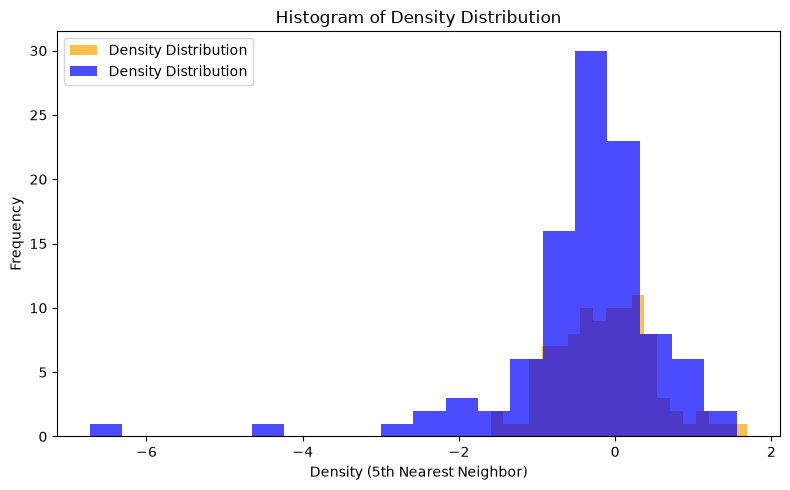

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(np.log10(dens[:,0][dens[:,-1] == 'barred'].astype(np.float64)), bins=20, label='Density Distribution', color='orange', alpha=0.7, cumulative=False)
plt.hist(np.log10(dens[:,0][dens[:,-1] == 'unbarred'].astype(np.float64)), bins=20, label='Density Distribution', color='blue', alpha=0.7, cumulative=False)
plt.xlabel('Density (5th Nearest Neighbor)')
plt.ylabel('Frequency')
plt.title('Histogram of Density Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../fig/density_distribution_histogram_STRM.png', dpi=300)
plt.show()

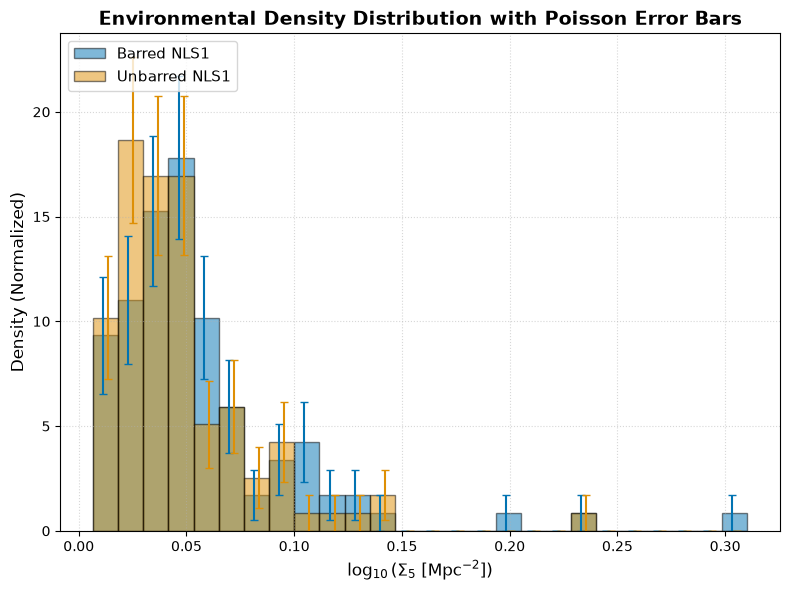

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 直接提取您的數據並轉為 float
b_dens = dens[:, 0][dens[:, -1] == 'barred'].astype(float)
ub_dens = dens[:, 0][dens[:, -1] == 'unbarred'].astype(float)

# 2. 完全交給算法自動決定最優分箱邊界 (bins='auto')，絕不人工限制
all_data = np.concatenate([b_dens, ub_dens])
bins = np.histogram_bin_edges(all_data, bins='auto')
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = np.diff(bins)  # 自動適應每個 bin 的實際寬度

# 3. 創建畫布
plt.figure(figsize=(8, 6))

# 4. 繪製標準的 overlapping plt.hist 並獲取每個 bin 的歸一化高度 (density=True)
b_heights, _, _ = plt.hist(b_dens, bins=bins, alpha=0.5, color='#0173b2', 
                           label='Barred NLS1', edgecolor='black', density=True)

ub_heights, _, _ = plt.hist(ub_dens, bins=bins, alpha=0.5, color='#de8f05', 
                            label='Unbarred NLS1', edgecolor='black', density=True)

# 5. 【拒絕任何 MC】直接解析計算每個 bin 的歸一化泊松誤差（Y 軸誤差棒）
# 獲取每個 bin 的原始星系計數 N
counts_b, _ = np.histogram(b_dens, bins=bins)
counts_ub, _ = np.histogram(ub_dens, bins=bins)

# 歸一化直方圖的泊松誤差公式： \sigma = \sqrt{N} / (N_total * bin_width)
b_bin_errs = np.sqrt(counts_b) / (len(b_dens) * bin_width)
ub_bin_errs = np.sqrt(counts_ub) / (len(ub_dens) * bin_width)

# 6. 在每個自動生成的柱子正上方繪製垂直誤差棒
# 左右微調 10% 的 bin 寬度，防止藍色和橙色的誤差棒完全重疊在一起
plt.errorbar(bin_centers - bin_width * 0.1, b_heights, yerr=b_bin_errs, 
             fmt='none', ecolor='#0173b2', elinewidth=1.5, capsize=3)

plt.errorbar(bin_centers + bin_width * 0.1, ub_heights, yerr=ub_bin_errs, 
             fmt='none', ecolor='#de8f05', elinewidth=1.5, capsize=3)

# 標籤與樣式 (使用 raw string 避免任何 SyntaxWarning)
plt.xlabel(r'$\log_{10}(\Sigma_5 \ [\mathrm{Mpc}^{-2}])$', fontsize=12)
plt.ylabel('Density (Normalized)', fontsize=12)
plt.title('Environmental Density Distribution with Poisson Error Bars', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# dens = []
# for i, idx in enumerate(index_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/redshift_STRM/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance_arcmin.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)


In [ ]:
# plt.hist(dens, bins = 50, label = 'Density Distribution', color = 'blue', alpha = 0.7)
# plt.xlabel('Density (5th Nearest Neighbor)')
# plt.ylabel('Frequency')
# plt.title('Histogram of Density Distribution')
# plt.legend()
# plt.savefig('../fig/density_distribution_histogram_STRM.png', dpi=300)
# plt.show()